In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("../../").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

## Load data

In [2]:
AGENT_ROOT = PROJECT_ROOT / "datasets" / "experiments" / "agent"

# Always pick the latest file in each folder
def latest(folder, pattern):
    files = sorted(folder.glob(pattern))
    assert files, f"No files matching {pattern} in {folder}"
    print(f"  {pattern}: {files[-1].name}")
    return files[-1]

print("Loading:")
div  = pd.read_csv(latest(AGENT_ROOT / "tasks/division",   "division_*.csv"))
ext  = pd.read_csv(latest(AGENT_ROOT / "tasks/extraction", "extraction_*.csv"),
                   usecols=["index","document","chunk_idx","type","relevance_score",
                            "input_tokens","output_tokens","latency_ms"])
meta = pd.read_csv(latest(AGENT_ROOT / "tasks/meta",       "meta_*.csv"))
qa   = pd.read_csv(latest(AGENT_ROOT / "results",          "qa_results_*.csv"))

# Normalise judge score (0-10) to [0, 1]
qa["score"] = qa["judge_score"] / 10.0

# Map company → index group
INDEX_MAP = {
    "Axa": "CAC40", "BNP Paribas": "CAC40", "LVMH": "CAC40", "Orange": "CAC40",
    "Sanofi": "CAC40", "Engie": "CAC40", "Suez": "CAC40",
    "Total Energies S.A": "CAC40", "Veolia Environment S.A": "CAC40",
    "BASF": "DAX", "Siemens AG": "DAX",
    "Ali Baba Group": "Other", "ArcelorMittal SA": "Other", "BP": "Other",
    "Baoshan Iron & Steel": "Other", "Hindustan Unilever": "Other",
    "NTPC": "Other", "Nestle": "Other", "Roche Holding AG": "Other",
    "SPD Bank": "Other", "Samsung": "Other", "Sinopharm": "Other",
    "Bank of America": "SP500", "AT&T": "SP500", "Apple": "SP500",
    "ExxonMobil": "SP500", "General Electric": "SP500", "Google": "SP500",
    "Meta": "SP500", "Microsoft": "SP500", "NVIDIA": "SP500",
    "Pfizer": "SP500", "Sysco": "SP500",
}
qa["index"] = qa["company"].map(INDEX_MAP).fillna("Other")

print(f"\nQA rows: {len(qa):,}  |  Extraction chunks: {len(ext):,}  |  PDFs: {len(meta):,}")

Loading:
  division_*.csv: division_20260624_143048.csv
  extraction_*.csv: extraction_20260624_143048.csv
  meta_*.csv: meta_20260624_143048.csv
  qa_results_*.csv: qa_results_20260624_234232.csv

QA rows: 6,270  |  Extraction chunks: 218  |  PDFs: 32


---
## Extraction Pipeline
How the agent divides and extracts content from ESG PDFs.

#### Plot 1 — Chunk type distribution & relevance scores
Left: how many chunks of each type were extracted across all documents.
Right: relevance score assigned by the extraction agent per chunk type.

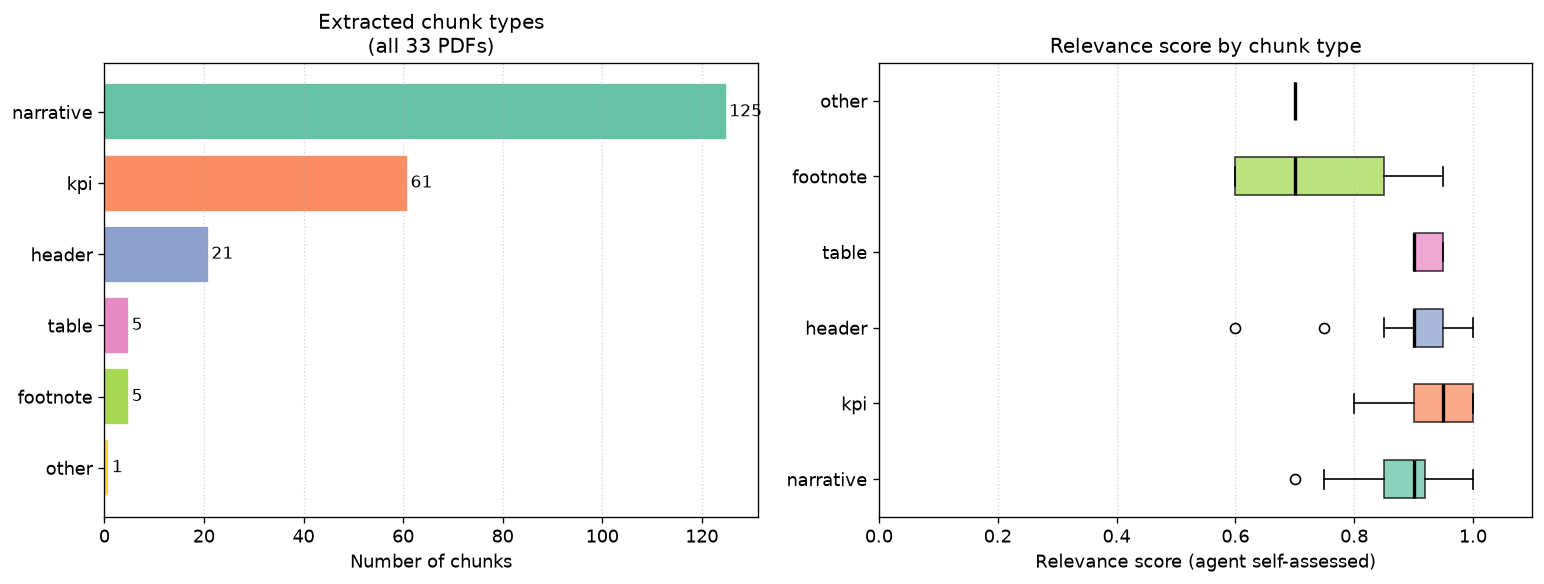

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: chunk type counts
type_counts = ext["type"].value_counts()
colors_bar  = plt.cm.Set2.colors
axes[0].barh(type_counts.index, type_counts.values,
             color=colors_bar[:len(type_counts)], edgecolor="white")
axes[0].set_xlabel("Number of chunks", fontsize=11)
axes[0].set_title("Extracted chunk types\n(all 33 PDFs)", fontsize=12)
axes[0].invert_yaxis()
for i, v in enumerate(type_counts.values):
    axes[0].text(v + 0.5, i, str(v), va="center", fontsize=10)
axes[0].grid(axis="x", linestyle=":", alpha=0.5)

# Right: relevance score box per type
order = type_counts.index.tolist()
data  = [ext[ext["type"] == t]["relevance_score"].dropna().values for t in order]
bp = axes[1].boxplot(data, vert=False, patch_artist=True,
                     medianprops=dict(color="black", linewidth=2))
axes[1].set_yticklabels(order)
for patch, color in zip(bp["boxes"], colors_bar):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[1].set_xlabel("Relevance score (agent self-assessed)", fontsize=11)
axes[1].set_title("Relevance score by chunk type", fontsize=12)
axes[1].set_xlim(0, 1.1)
axes[1].grid(axis="x", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

#### Plot 2 — Document size vs pipeline cost
Left: total pages per document vs division latency — does a longer doc take longer to divide?
Right: number of chunks extracted per document, coloured by index group.

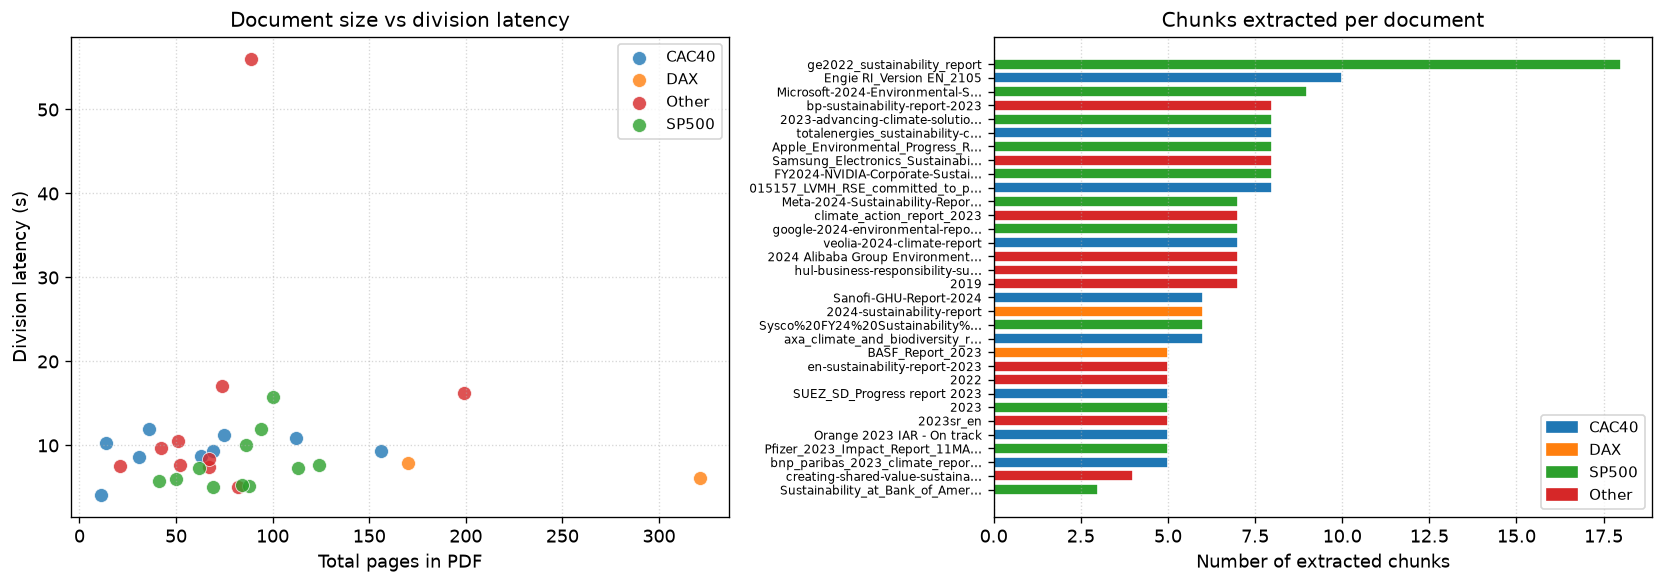

In [4]:
index_colors = {"CAC40": "#1f77b4", "DAX": "#ff7f0e", "SP500": "#2ca02c", "Other": "#d62728"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: pages vs division latency scatter
for idx, grp in meta.groupby("index"):
    axes[0].scatter(grp["total_pages"], grp["division_latency_ms"] / 1000,
                    label=idx, color=index_colors.get(idx, "grey"),
                    s=70, alpha=0.8, edgecolors="white", linewidth=0.5)
axes[0].set_xlabel("Total pages in PDF", fontsize=11)
axes[0].set_ylabel("Division latency (s)", fontsize=11)
axes[0].set_title("Document size vs division latency", fontsize=12)
axes[0].legend(fontsize=9)
axes[0].grid(linestyle=":", alpha=0.5)

# Right: extractions per document (horizontal bar, sorted)
meta_sorted = meta.sort_values("num_extractions", ascending=True)
bar_colors  = [index_colors.get(i, "grey") for i in meta_sorted["index"]]
short_names = [d[:30] + "…" if len(d) > 30 else d for d in meta_sorted["document"]]
axes[1].barh(range(len(meta_sorted)), meta_sorted["num_extractions"],
             color=bar_colors, edgecolor="white")
axes[1].set_yticks(range(len(meta_sorted)))
axes[1].set_yticklabels(short_names, fontsize=7)
axes[1].set_xlabel("Number of extracted chunks", fontsize=11)
axes[1].set_title("Chunks extracted per document", fontsize=12)
axes[1].grid(axis="x", linestyle=":", alpha=0.5)
patches = [mpatches.Patch(color=c, label=l) for l, c in index_colors.items()]
axes[1].legend(handles=patches, fontsize=9, loc="lower right")

plt.tight_layout()
plt.show()

---
## Agent QA Performance
The agent pipeline (supervisor + 3 sub-agents) is evaluated on the full CFB dataset
(6 270 rows, 3 perturbation levels). Judge score normalised from 0–10 to 0–1.

#### Plot 3 — Score by question type & perturbation level
Left: mean score per question type (NR / LR / PE).
Right: how each question type degrades across perturbation levels 0→3.

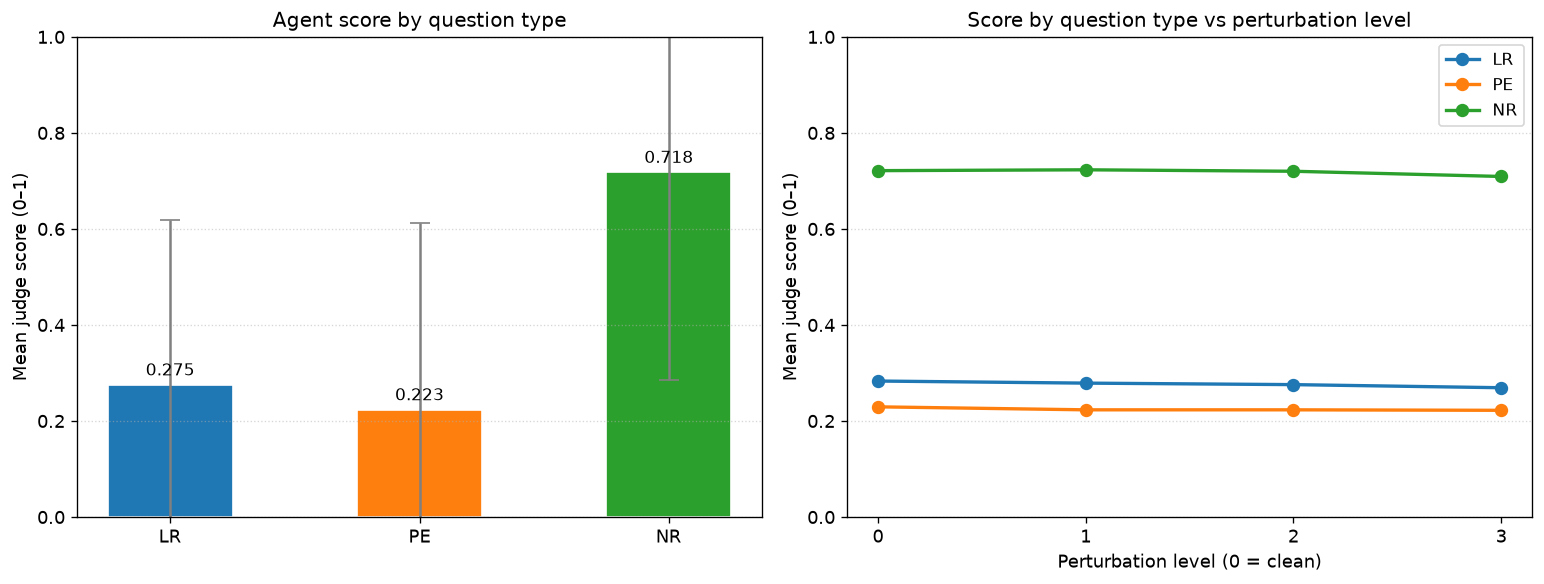

In [5]:
type_colors = {"LR": "#1f77b4", "PE": "#ff7f0e", "NR": "#2ca02c"}
levels = [0, 1, 2, 3]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: bar chart by question type
means = {qt: qa[qa["question_type"] == qt]["score"].mean() for qt in ["LR", "PE", "NR"]}
stds  = {qt: qa[qa["question_type"] == qt]["score"].std()  for qt in ["LR", "PE", "NR"]}
axes[0].bar(means.keys(), means.values(),
            color=[type_colors[k] for k in means],
            yerr=stds.values(), capsize=6, edgecolor="white", width=0.5,
            error_kw={"elinewidth": 1.5, "ecolor": "grey"})
axes[0].set_ylabel("Mean judge score (0–1)", fontsize=11)
axes[0].set_title("Agent score by question type", fontsize=12)
axes[0].set_ylim(0, 1.0)
axes[0].grid(axis="y", linestyle=":", alpha=0.5)
for qt, mean in means.items():
    axes[0].text(list(means.keys()).index(qt), mean + 0.02, f"{mean:.3f}",
                 ha="center", fontsize=10)

# Right: line per question type across perturbation levels
for qt, color in type_colors.items():
    ys = [qa[(qa["question_type"] == qt) & (qa["perturbation_level"] == lvl)]["score"].mean()
          for lvl in levels]
    axes[1].plot(levels, ys, "o-", color=color, linewidth=2, markersize=7, label=qt)
axes[1].set_xlabel("Perturbation level (0 = clean)", fontsize=11)
axes[1].set_ylabel("Mean judge score (0–1)", fontsize=11)
axes[1].set_title("Score by question type vs perturbation level", fontsize=12)
axes[1].set_xticks(levels)
axes[1].set_ylim(0, 1.0)
axes[1].legend(fontsize=10)
axes[1].grid(axis="y", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

#### Plot 4 — Perturbation type impact & tool usage
Left: mean score drop at perturbation level 3 per perturbation type (vs clean baseline).
Right: how often each tool was called by the agent across all queries.

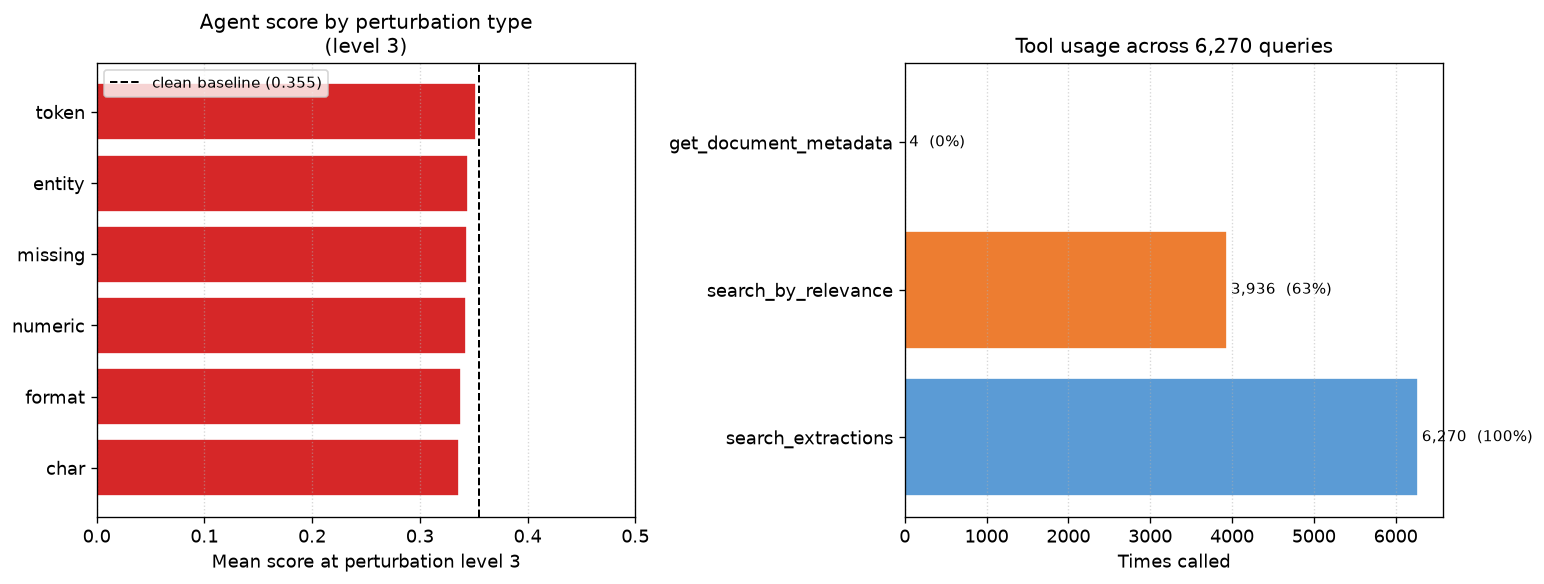

In [6]:
import json as _json
from collections import Counter

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: score at level 3 by perturbation type
baseline   = qa[qa["perturbation_level"] == 0]["score"].mean()
ptypes     = [pt for pt in qa["perturbation_type"].unique() if pt != "none"]
pt_means   = {pt: qa[(qa["perturbation_type"] == pt) & (qa["perturbation_level"] == 3)]["score"].mean()
              for pt in ptypes}
pt_sorted  = sorted(pt_means.items(), key=lambda x: x[1])
bar_colors = ["#d62728" if v < baseline else "#aec7e8" for _, v in pt_sorted]

axes[0].barh([p for p, _ in pt_sorted], [v for _, v in pt_sorted],
             color=bar_colors, edgecolor="white")
axes[0].axvline(baseline, color="black", linewidth=1.2, linestyle="--",
                label=f"clean baseline ({baseline:.3f})")
axes[0].set_xlabel("Mean score at perturbation level 3", fontsize=11)
axes[0].set_title("Agent score by perturbation type\n(level 3)", fontsize=12)
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, 0.5)
axes[0].grid(axis="x", linestyle=":", alpha=0.5)

# Right: tool usage
tools_flat = []
for t in qa["tools_used"].dropna():
    try: tools_flat.extend(_json.loads(t))
    except: pass
tool_counts = Counter(tools_flat)
axes[1].barh(list(tool_counts.keys()), list(tool_counts.values()),
             color=["#5b9bd5", "#ed7d31", "#70ad47"][:len(tool_counts)], edgecolor="white")
axes[1].set_xlabel("Times called", fontsize=11)
axes[1].set_title(f"Tool usage across {len(qa):,} queries", fontsize=12)
axes[1].grid(axis="x", linestyle=":", alpha=0.5)
for i, (tool, count) in enumerate(tool_counts.items()):
    axes[1].text(count + 50, i, f"{count:,}  ({count/len(qa)*100:.0f}%)",
                 va="center", fontsize=9)

plt.tight_layout()
plt.show()

#### Plot 5 — Supervisor confidence & score by company group
Left: distribution of supervisor confidence values (0 = not confident, 1 = confident).
Right: mean agent score per company index group (CAC40 / DAX / SP500 / Other).

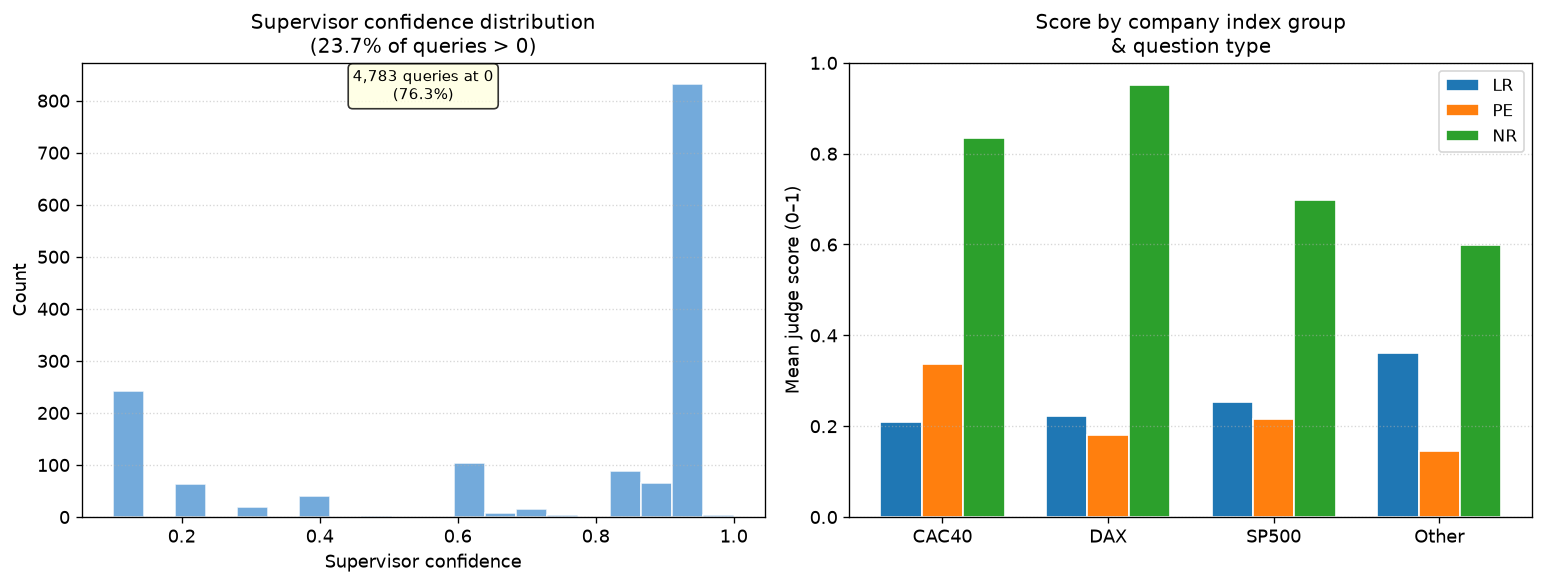

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: supervisor confidence histogram
conf = qa["supervisor_confidence"]
axes[0].hist(conf[conf > 0], bins=20, color="#5b9bd5", edgecolor="white", alpha=0.85)
pct_confident = (conf > 0).mean() * 100
axes[0].set_xlabel("Supervisor confidence", fontsize=11)
axes[0].set_ylabel("Count", fontsize=11)
axes[0].set_title(f"Supervisor confidence distribution\n"
                  f"({pct_confident:.1f}% of queries > 0)", fontsize=12)
axes[0].grid(axis="y", linestyle=":", alpha=0.5)
zero_count = (conf == 0).sum()
axes[0].text(0.5, 0.92, f"{zero_count:,} queries at 0\n({100-pct_confident:.1f}%)",
             transform=axes[0].transAxes, ha="center", fontsize=9,
             bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

# Right: score by index group, split by question type
idx_order  = ["CAC40", "DAX", "SP500", "Other"]
x          = np.arange(len(idx_order))
width      = 0.25
for i, (qt, color) in enumerate(type_colors.items()):
    means = [qa[(qa["index"] == idx) & (qa["question_type"] == qt)]["score"].mean()
             for idx in idx_order]
    axes[1].bar(x + i * width, means, width, label=qt, color=color, edgecolor="white")

axes[1].set_xticks(x + width)
axes[1].set_xticklabels(idx_order, fontsize=11)
axes[1].set_ylabel("Mean judge score (0–1)", fontsize=11)
axes[1].set_title("Score by company index group\n& question type", fontsize=12)
axes[1].legend(fontsize=10)
axes[1].set_ylim(0, 1.0)
axes[1].grid(axis="y", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()